# Phase 5/7 — Notebook 26 **v3**: Benign-Only Reference + Persistence Trigger

**Notebook:** `notebooks/07_phase5_adaptation/26_benign_reference_trigger.ipynb` (v3)
**Pre-registration:** A3 (v1) → A4 (v2) → **A5 (this run)** — commit A5 with date + git hash BEFORE running.

**History, kept honest.**
- **v1 (A3):** benign-only reference removed the composition artifact (control quiet score ≈0.47 vs treatment ≈0.013, τ≈0.015) but bootstrap calibration under-dispersed the null → marginal fires; Wilson gate unsatisfiable at n=10. Deviation A3.7.
- **v2 (A4):** Phase-I/II calibration, τ_eff = max of 4 disjoint nulls → **predictably** beaten by multiplicity: per-window exceedance = 1/5 under exchangeability → expected 8/5 = 1.6 quiet fires; 2/8 observed at every breadth. Also surfaced: a quiet false fire retrains the detector on a benign-only pool (pool-replacement semantics) — false alarms are destructive, not just wasteful. Deviation A4.
- **v3 (A5), two standard-SPC changes:** (1) **persistence** — fire only on K_PERSIST=2 consecutive exceedances (isolated noise-band crossings become non-events; ≤ +1 latency on contiguous drift); (2) **strengthened null** — τ_eff = max( max of 6 disjoint nulls (2 CAL + 4 burn-in), Q_0.999 of 200 permutation draws ). Pre-registered arithmetic (A5.3): expected quiet FIRES ≈ 0.10 per stream → the 0-fires gate is satisfiable by construction.

**Gates (A5.4):** G-FA (0 quiet fires, every breadth; exceedances reported) ∧ G-DET (first fire ≤ 2 windows after onset; treatment t2500 recall ≥ control − 0.05) → **ARTIFACT-FIXED-V3**. If v3 fails: no v4 threshold tuning — the pre-registered terminus is a characterized limitation (a different monitor statistic would need its own prereg).

**Runtime:** ≈ v2 (~30–60 min).

## 1. Environment + pre-registered configuration (A5)

In [1]:
import sys
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass
THESIS_ROOT = Path('/content/drive/MyDrive/phd_thesis')
if str(THESIS_ROOT) not in sys.path:
    sys.path.insert(0, str(THESIS_ROOT))

import numpy as np, pandas as pd, json, time, math, glob, inspect
from datetime import date
import matplotlib.pyplot as plt

from src.utils.seeding import set_global_seed
from src.utils.io import path
from src.utils.documentation import log_finding
from src.streaming.replay import train_detector
from src.monitoring.ks_monitor import KSMonitor, per_feature_ks
from src.adaptation.cost_eval import run_instrumented, micro_metrics
assert 'always_cheap' in inspect.getsource(run_instrumented), \
    'cost_eval is not the v2; run the notebook-20 cell that writes it first.'

SEED = 42; set_global_seed(SEED)
RF_KW = dict(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)

# --- nb21 construction, verbatim (D039) ---
BREADTHS      = [1, 2, 4]
WINDOW_SIZE   = 5000
QUIET_WINDOWS = 10
TRAIN_BENIGN  = 25000
K_SIGMA, REF_FRAC = 3.0, 0.50

# --- A5 (v3) ---
BURN_IN    = 4        # quiet stream windows consumed as Phase-I nulls
N_PERM     = 200      # permutation null draws for the quantile term
PERM_Q     = 0.999    # empirical quantile of the permutation null
K_PERSIST  = 2        # consecutive exceedances required to FIRE
L_MAX      = 2        # persistence adds <= 1 window of latency
RECALL_MARGIN = 0.05
print('Config set. v3: benign-only reference + persistence (K=2) + '
      f'strengthened null (6 disjoint + Q{PERM_Q} of {N_PERM} permutations).')

Mounted at /content/drive
Config set. v3: benign-only reference + persistence (K=2) + strengthened null (6 disjoint + Q0.999 of 200 permutations).


## 2. Load UNSW (nb21's inline loader, verbatim)

In [2]:
def _find_unsw_files():
    pats = ['unsw*.parquet', 'UNSW*.parquet', '*unsw*.parquet']
    for sub in ('data/processed', 'data/interim', 'data/raw'):
        d = THESIS_ROOT / sub
        if not d.exists():
            continue
        hits = []
        for p in pats:
            hits += list(d.rglob(p))
        if hits:
            return ('parquet', sorted(set(hits)))
    for sub in ('data/raw', 'data/raw/unsw_nb15', 'data/raw/UNSW-NB15'):
        d = THESIS_ROOT / sub
        if d.exists():
            csvs = [c for c in sorted(d.rglob('*.csv')) if 'unsw' in c.name.lower()]
            if csvs:
                return ('csv', csvs)
    return (None, [])

def _pick(df, names):
    low = {c.lower(): c for c in df.columns}
    for nm in names:
        if nm.lower() in low:
            return low[nm.lower()]
    return None

kind, files = _find_unsw_files()
assert kind is not None, 'No UNSW parquet/csv found.'
df_raw = (pd.concat([pd.read_parquet(p) for p in files], ignore_index=True) if kind == 'parquet'
          else pd.concat([pd.read_csv(p, low_memory=False) for p in files], ignore_index=True))
cat_col = _pick(df_raw, ['attack_category', 'attack_cat', 'attackcat', 'category'])
lab_col = _pick(df_raw, ['label', 'Label', 'is_attack'])
id_like = [c for c in df_raw.columns if c.lower() in (
    'id', 'srcip', 'dstip', 'sport', 'dsport', 'stime', 'ltime', 'source_file', 'attempted')]
fams = df_raw[cat_col].astype(str).str.strip().str.lower().replace(
    {'': 'benign', 'normal': 'benign', 'nan': 'benign', '-': 'benign'})
feat = df_raw.drop(columns=[c for c in [cat_col, lab_col] + id_like if c], errors='ignore')
feat = feat.apply(pd.to_numeric, errors='coerce')
feat = feat.loc[:, feat.notna().mean() > 0.99].fillna(0.0).astype('float32')
X_all = feat.to_numpy(); fam = fams.to_numpy()
y_attack = (fam != 'benign').astype(int)
is_benign = (fam == 'benign')
attack_order = list(pd.Series(fam[y_attack == 1]).value_counts().index)
print(f'UNSW {kind}: {feat.shape[1]} features; attack rate {y_attack.mean():.3f}')
print('attack families (largest first):', attack_order)

UNSW parquet: 42 features; attack rate 0.639
attack families (largest first): ['generic', 'exploits', 'fuzzers', 'dos', 'reconnaissance', 'analysis', 'backdoor', 'shellcode', 'worms']


## 3. Helpers: nb21 regime builder (verbatim) + v3 calibration + persistence runner

In [3]:
def windows_of(n, size):
    b = list(range(0, n, size)) + [n]
    return [(b[i], b[i + 1]) for i in range(len(b) - 1)]

def wilson(k, n, z=1.96):
    if n == 0:
        return (float('nan'), float('nan'))
    p = k / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (max(0.0, c - h), min(1.0, c + h))

def build_regime(seen_fams):
    novel_fams = [f for f in attack_order if f not in seen_fams]
    rng = np.random.default_rng(SEED)
    benign_idx = np.where(is_benign)[0]; rng.shuffle(benign_idx)
    seen_idx = np.where(np.isin(fam, seen_fams))[0]
    novel_idx = np.where(np.isin(fam, novel_fams))[0]; rng.shuffle(novel_idx)
    n_trb = min(TRAIN_BENIGN, len(benign_idx) // 2)
    warm = np.concatenate([benign_idx[:n_trb], seen_idx]); rng.shuffle(warm)
    Xtr, ytr = X_all[warm], y_attack[warm]
    warm_benign_pos = np.flatnonzero(y_attack[warm] == 0)
    rest_benign = benign_idx[n_trb:]
    q_take = min(len(rest_benign), QUIET_WINDOWS * WINDOW_SIZE)
    quiet_rows = rest_benign[:q_take]; drift_benign = rest_benign[q_take:]
    n_fill = min(len(drift_benign), len(novel_idx))
    drift_rows = np.concatenate([novel_idx, drift_benign[:n_fill]]); rng.shuffle(drift_rows)
    stream_idx = np.concatenate([quiet_rows, drift_rows])
    Xs, ys, fam_s = X_all[stream_idx], y_attack[stream_idx], fam[stream_idx]
    wins = windows_of(len(Xs), WINDOW_SIZE)
    is_drift = [bool(np.isin(fam_s[a:b], novel_fams).any()) for (a, b) in wins]
    return dict(Xtr=Xtr, ytr=ytr, warm_benign_pos=warm_benign_pos,
                Xs=Xs, ys=ys, windows=wins, is_drift=is_drift, novel=novel_fams)

def tau_v3(REF_T, cal_pool, burn_windows, seed):
    """A5.2: tau_eff = max( max of disjoint nulls, empirical PERM_Q quantile
    of N_PERM permutation draws from pooled CAL + burn-in rows )."""
    disjoint = [cal_pool[a:b] for (a, b) in windows_of(len(cal_pool), WINDOW_SIZE)
                if b - a == WINDOW_SIZE] + list(burn_windows)
    d_scores = [float(per_feature_ks(REF_T, w).mean()) for w in disjoint]
    pool = np.vstack([cal_pool] + list(burn_windows))
    rng = np.random.default_rng(seed)
    p_scores = []
    for _ in range(N_PERM):
        idx = rng.choice(len(pool), size=WINDOW_SIZE, replace=False)
        p_scores.append(float(per_feature_ks(REF_T, pool[idx]).mean()))
    tau_disjoint = max(d_scores)
    tau_perm = float(np.quantile(p_scores, PERM_Q))
    return dict(tau_eff=max(tau_disjoint, tau_perm),
                tau_disjoint=tau_disjoint, tau_perm=tau_perm,
                n_disjoint=len(d_scores), disjoint_scores=d_scores)

def run_triggered_persist(Xs, ys, windows, det0, rf_kw, reference0, tau,
                          budget, k_persist=2, seed=42):
    """Triggered policy with a K-consecutive persistence rule. Retrain/pool/
    reference semantics copied verbatim from cost_eval.run_instrumented's
    'triggered' branch; the ONLY change is the fire condition. Promote to
    src/adaptation/ if A5 gates pass (nb17 promotion pattern)."""
    rng = np.random.default_rng(seed)
    rows, triggers, exceedances = [], [], []
    labels = 0; compute = 0.0
    cur = det0
    ref = np.asarray(reference0)
    poolX, poolY = [], []
    streak = 0
    for i, (a, b) in enumerate(windows):
        Xi, yi = Xs[a:b], ys[a:b]
        rt = 0.0; spent = 0
        tp = int(((cur.predict(Xi) == 1) & (yi == 1)).sum())  # placeholder; recompute below
        pred = cur.predict(Xi)
        tp = int(((pred == 1) & (yi == 1)).sum()); fp = int(((pred == 1) & (yi == 0)).sum())
        fn = int(((pred == 0) & (yi == 1)).sum()); tn = int(((pred == 0) & (yi == 0)).sum())

        score = float(per_feature_ks(ref, Xi).mean())
        exceed = bool(score > tau)
        if exceed:
            exceedances.append(i)
        streak = streak + 1 if exceed else 0
        if streak >= k_persist:
            triggers.append(i)
            k = min(budget, len(Xi))
            idx = rng.choice(len(Xi), size=k, replace=False)
            poolX.append(Xi[idx]); poolY.append(yi[idx])
            t = time.time()
            cur = train_detector(np.concatenate(poolX), np.concatenate(poolY), rf_kw)
            rt = time.time() - t
            spent = k
            ref = Xi
            streak = 0
        labels += spent; compute += rt
        rows.append(dict(window=i, tp=tp, fp=fp, fn=fn, tn=tn,
                         retrained=(spent > 0), retrain_s=rt, labels=spent,
                         score=score, exceed=exceed))
    return dict(policy=f'triggered_persist_{budget}', per_window=rows,
                label_cost=labels, compute_s=compute,
                n_retrains=len(triggers), triggers=triggers,
                exceedances=exceedances)

print('helpers ready.')

helpers ready.


## 4. Adjacency diagnostic — answers P-A5-3 before the sweep

Recomputes the v2 situation statically (τ_eff-v2 = max of 4 nulls, quiet
windows 2–9) and reports whether the exceedances were isolated or adjacent —
the question the v2 PDF could not answer, and the risk condition for the
persistence rule.

In [4]:
R0 = build_regime(attack_order[:BREADTHS[0]])
Xs0, wins0, is_drift0 = R0['Xs'], R0['windows'], R0['is_drift']
bpos = R0['warm_benign_pos']
bperm = np.random.default_rng(SEED).permutation(len(bpos))
half = len(bpos) // 2
REF_T0 = R0['Xtr'][bpos[bperm[:half]]]
CAL_T0 = R0['Xtr'][bpos[bperm[half:]]]

# v2's nulls: 2 contiguous CAL windows + first 2 quiet windows
v2_nulls = [CAL_T0[a:b] for (a, b) in windows_of(len(CAL_T0), WINDOW_SIZE)
            if b - a == WINDOW_SIZE]
v2_nulls += [Xs0[wins0[i][0]:wins0[i][1]] for i in range(2)]
tau_v2 = max(float(per_feature_ks(REF_T0, w).mean()) for w in v2_nulls)

quiet_all = [i for i, d in enumerate(is_drift0) if not d]
scores_q = {i: float(per_feature_ks(REF_T0, Xs0[wins0[i][0]:wins0[i][1]]).mean())
            for i in quiet_all}
exc_v2 = [i for i in quiet_all[2:] if scores_q[i] > tau_v2]   # v2 monitored from window 2
adjacent = any(j - i == 1 for i, j in zip(exc_v2, exc_v2[1:]))
print(f'tau_v2 (max of 4 nulls) = {tau_v2:.4f}')
print('quiet scores:', {i: round(s, 4) for i, s in scores_q.items()})
print(f'v2-style exceedances at windows {exc_v2} -> '
      f"{'ADJACENT (persistence alone would NOT have sufficed)' if adjacent else 'ISOLATED (persistence suffices)'}")

tau_v2 (max of 4 nulls) = 0.0114
quiet scores: {0: 0.0114, 1: 0.0092, 2: 0.01, 3: 0.0144, 4: 0.0111, 5: 0.0117, 6: 0.0109, 7: 0.011, 8: 0.016, 9: 0.0125}
v2-style exceedances at windows [3, 5, 8, 9] -> ADJACENT (persistence alone would NOT have sufficed)


## 5. The two-arm sweep (control verbatim; treatment = v3)

Control arm: nb21 monitor exactly (mixed reference, contiguous mixed
calibration, no persistence) — the historical reference row. Treatment arm:
benign-only reference, τ_eff from A5.2, persistence K=2, monitored from
window BURN_IN (burn-in windows are Phase-I nulls, neither monitored nor
counted).

In [5]:
results = []
t0 = time.time()
for b in BREADTHS:
    seen = attack_order[:b]
    R = build_regime(seen)
    Xtr, ytr = R['Xtr'], R['ytr']
    Xs, ys, wins, is_drift = R['Xs'], R['ys'], R['windows'], R['is_drift']
    quiet_idx = [i for i, d in enumerate(is_drift) if not d]
    onset = next(i for i, d in enumerate(is_drift) if d)
    det0 = train_detector(Xtr, ytr, RF_KW)

    # ---- control monitor: nb21 verbatim ----
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(Xtr)); n_ref = int(REF_FRAC * len(Xtr))
    REF_C, Xcal_C = Xtr[perm[:n_ref]], Xtr[perm[n_ref:]]
    mon_c = KSMonitor(REF_C)
    mon_c.calibrate([Xcal_C[a:b2] for (a, b2) in windows_of(len(Xcal_C), WINDOW_SIZE)],
                    k=K_SIGMA)
    o250c = run_instrumented(Xs, ys, wins, det0, RF_KW, policy='triggered',
                             reference0=REF_C, tau=mon_c.tau, budget=250)
    o2500c = run_instrumented(Xs, ys, wins, det0, RF_KW, policy='triggered',
                              reference0=REF_C, tau=mon_c.tau, budget=2500)
    trg_c = sorted(o250c['triggers'])
    fa_kc = sum(1 for i in quiet_idx if i in set(trg_c))
    lat_c = next((i for i in trg_c if i >= onset), None)
    lat_c = None if lat_c is None else lat_c - onset

    # ---- treatment monitor: v3 ----
    bpos = R['warm_benign_pos']
    bperm = np.random.default_rng(SEED).permutation(len(bpos))
    half = len(bpos) // 2
    REF_T = Xtr[bpos[bperm[:half]]]
    CAL_T = Xtr[bpos[bperm[half:]]]
    burn = [Xs[wins[i][0]:wins[i][1]] for i in range(BURN_IN)]
    cal = tau_v3(REF_T, CAL_T, burn, SEED)
    tau_t = cal['tau_eff']

    start_row = wins[BURN_IN][0]
    wins_t = [(a - start_row, b2 - start_row) for (a, b2) in wins[BURN_IN:]]
    Xs_t, ys_t = Xs[start_row:], ys[start_row:]
    drift_t = is_drift[BURN_IN:]
    quiet_t = [i for i, d in enumerate(drift_t) if not d]
    onset_t = next(i for i, d in enumerate(drift_t) if d)

    o250t = run_triggered_persist(Xs_t, ys_t, wins_t, det0, RF_KW,
                                  reference0=REF_T, tau=tau_t, budget=250,
                                  k_persist=K_PERSIST, seed=SEED)
    o2500t = run_triggered_persist(Xs_t, ys_t, wins_t, det0, RF_KW,
                                   reference0=REF_T, tau=tau_t, budget=2500,
                                   k_persist=K_PERSIST, seed=SEED)
    trg_t = sorted(o250t['triggers'])
    exc_t = sorted(o250t['exceedances'])
    fires_quiet = sum(1 for i in quiet_t if i in set(trg_t))
    exc_quiet = [i for i in quiet_t if i in set(exc_t)]
    lat_t = next((i for i in trg_t if i >= onset_t), None)
    lat_t = None if lat_t is None else lat_t - onset_t

    rec = lambda o, m: micro_metrics(o['per_window'], mask=m)['recall']
    results.append(dict(
        breadth=b, seen=seen, novel=R['novel'],
        onset=onset, onset_t=onset_t, n_quiet_t=len(quiet_t),
        control=dict(tau=float(mon_c.tau), fa_k=fa_kc, fa_n=len(quiet_idx),
                     latency=lat_c, triggers=trg_c,
                     recall_t2500=rec(o2500c, is_drift),
                     recall_t250=rec(o250c, is_drift),
                     labels_t250=o250c['label_cost']),
        treatment=dict(tau=float(tau_t), tau_disjoint=cal['tau_disjoint'],
                       tau_perm=cal['tau_perm'],
                       fires_quiet=fires_quiet, n_quiet=len(quiet_t),
                       exceed_quiet=exc_quiet, triggers=trg_t,
                       latency=lat_t,
                       recall_t2500=rec(o2500t, drift_t),
                       recall_t250=rec(o250t, drift_t),
                       labels_t250=o250t['label_cost'])))
    c = results[-1]['control']; a = results[-1]['treatment']
    print(f"breadth {b}: ctrl FA {c['fa_k']}/{c['fa_n']} lat {c['latency']} "
          f"t2500 {c['recall_t2500']:.3f} | treat fires {a['fires_quiet']}/{a['n_quiet']} "
          f"(exceed at {a['exceed_quiet']}) lat {a['latency']} "
          f"t2500 {a['recall_t2500']:.3f} | tau_eff {a['tau']:.4f} "
          f"(disjoint {a['tau_disjoint']:.4f}, perm {a['tau_perm']:.4f}) "
          f"({time.time()-t0:.0f}s)")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

breadth 1: ctrl FA 1/10 lat 0 t2500 0.868 | treat fires 0/6 (exceed at []) lat 1 t2500 0.966 | tau_eff 0.0173 (disjoint 0.0144, perm 0.0173) (19s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

breadth 2: ctrl FA 1/10 lat 0 t2500 0.914 | treat fires 0/6 (exceed at []) lat 1 t2500 0.956 | tau_eff 0.0187 (disjoint 0.0148, perm 0.0187) (37s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

breadth 4: ctrl FA 2/10 lat 0 t2500 0.842 | treat fires 0/6 (exceed at []) lat 1 t2500 0.987 | tau_eff 0.0175 (disjoint 0.0132, perm 0.0175) (54s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


## 6. Trace figure — scores, τ_eff, exceedances vs fires

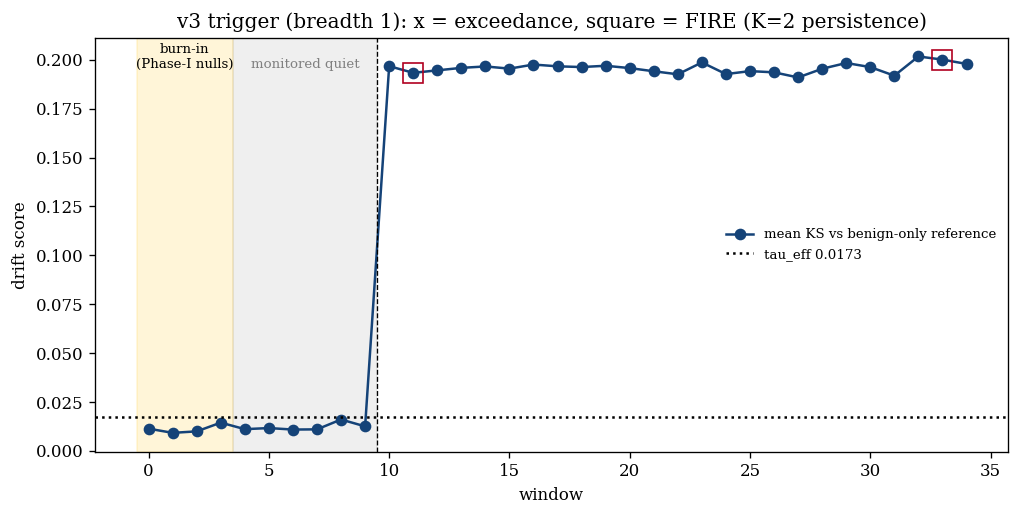

In [6]:
plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                     'figure.dpi': 120, 'savefig.dpi': 300})
b_show = BREADTHS[0]
r = next(x for x in results if x['breadth'] == b_show)
R = build_regime(attack_order[:b_show])
Xs, wins = R['Xs'], R['windows']
bpos = R['warm_benign_pos']
bperm = np.random.default_rng(SEED).permutation(len(bpos))
REF_T = R['Xtr'][bpos[bperm[:len(bpos)//2]]]
scores = [float(per_feature_ks(REF_T, Xs[a:b2]).mean()) for (a, b2) in wins]

fig, ax = plt.subplots(figsize=(8.6, 4.4))
w = np.arange(len(wins))
ax.plot(w, scores, 'o-', color='#154378', label='mean KS vs benign-only reference')
ax.axhline(r['treatment']['tau'], ls=':', color='black',
           label=f"tau_eff {r['treatment']['tau']:.4f}")
ax.axvspan(-0.5, BURN_IN - 0.5, color='#FFD966', alpha=0.25)
ax.text(BURN_IN / 2 - 0.5, max(scores) * 0.97, 'burn-in\n(Phase-I nulls)',
        ha='center', fontsize=8)
ax.axvspan(BURN_IN - 0.5, r['onset'] - 0.5, color='grey', alpha=0.12)
ax.text((BURN_IN + r['onset']) / 2 - 0.5, max(scores) * 0.97, 'monitored quiet',
        ha='center', fontsize=8, color='grey')
ax.axvline(r['onset'] - 0.5, color='black', lw=0.8, ls='--')
for i in r['treatment']['exceed_quiet']:
    ax.plot(i + BURN_IN, scores[i + BURN_IN], 'x', color='#B00020', ms=10, mew=2)
for i in r['treatment']['triggers']:
    ax.plot(i + BURN_IN, scores[i + BURN_IN], 's', mfc='none', mec='#B00020', ms=12)
ax.set_xlabel('window'); ax.set_ylabel('drift score')
ax.set_title(f'v3 trigger (breadth {b_show}): x = exceedance, square = FIRE '
             f'(K={K_PERSIST} persistence)')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
path('reports', 'figures').mkdir(parents=True, exist_ok=True)
for ext in ['png', 'pdf']:
    fig.savefig(path('reports', 'figures') / f'26_trigger_v3_trace.{ext}')
plt.show()

## 7. Gates (A5.4) and verdict

In [7]:
g_fa = all(r['treatment']['fires_quiet'] == 0 for r in results)
g_det = all((r['treatment']['latency'] is not None)
            and (r['treatment']['latency'] <= L_MAX)
            and (r['treatment']['recall_t2500']
                 >= r['control']['recall_t2500'] - RECALL_MARGIN)
            for r in results)

verdict = ('ARTIFACT-FIXED-V3' if (g_fa and g_det) else
           'FIX-COSTS-SENSITIVITY' if (g_fa and not g_det) else
           'FIX-INSUFFICIENT-V3')

rows = []
for r in results:
    c, a = r['control'], r['treatment']
    rows.append(dict(breadth=r['breadth'], arm='control', tau=round(c['tau'], 4),
                     quiet_events=f"{c['fa_k']}/{c['fa_n']} fires",
                     latency=c['latency'], t2500_recall=round(c['recall_t2500'], 3),
                     t250_labels=c['labels_t250']))
    rows.append(dict(breadth=r['breadth'], arm='treatment_v3', tau=round(a['tau'], 4),
                     quiet_events=(f"{a['fires_quiet']}/{a['n_quiet']} fires; "
                                   f"exceed@{a['exceed_quiet']}"),
                     latency=a['latency'], t2500_recall=round(a['recall_t2500'], 3),
                     t250_labels=a['labels_t250'],
                     tau_disjoint=round(a['tau_disjoint'], 4),
                     tau_perm=round(a['tau_perm'], 4)))
tab = pd.DataFrame(rows)
display(tab)
path('reports', 'tables').mkdir(parents=True, exist_ok=True)
tab.to_csv(path('reports', 'tables') / '26_benign_reference_trigger_v3.csv', index=False)

print('=' * 76)
print('BENIGN-ONLY REFERENCE + PERSISTENCE TRIGGER — A5 VERDICT (v3)')
print('=' * 76)
print(f'  G-FA  (0 quiet fires, all breadths; expected ~0.10 under A5.3): {g_fa}')
print(f'  G-DET (latency <= {L_MAX}; t2500 recall within {RECALL_MARGIN}): {g_det}')
print(f'  P-A5-2 (latency exactly 1): '
      f"{[(r['breadth'], r['treatment']['latency']) for r in results]}")
print('-' * 76)
print(f'--> VERDICT: {verdict}')
if verdict == 'ARTIFACT-FIXED-V3':
    print('    -> promote run_triggered_persist + tau_v3 to src/adaptation/, then '
          'build notebook 27 (nb22 regime-gate re-confirmation, fresh prereg).')
elif verdict == 'FIX-INSUFFICIENT-V3':
    print('    -> pre-registered terminus (A5.4): no v4 threshold tuning. Report '
          'artifact-removed + characterized noise-band selectivity; a different '
          'monitor statistic (EWMA/CUSUM) would need its own prereg.')

,breadth,arm,tau,quiet_events,latency,t2500_recall,t250_labels,tau_disjoint,tau_perm
0,1,control,0.0155,1/10 fires,0,0.868,500,NaN,NaN
1,1,treatment_v3,0.0173,0/6 fires; exceed@[],1,0.966,500,0.0144,0.0173
2,2,control,0.0147,1/10 fires,0,0.914,2000,NaN,NaN
3,2,treatment_v3,0.0187,0/6 fires; exceed@[],1,0.956,250,0.0148,0.0187
4,4,control,0.0128,2/10 fires,0,0.842,1750,NaN,NaN
5,4,treatment_v3,0.0175,0/6 fires; exceed@[],1,0.987,250,0.0132,0.0175


BENIGN-ONLY REFERENCE + PERSISTENCE TRIGGER — A5 VERDICT (v3)
  G-FA  (0 quiet fires, all breadths; expected ~0.10 under A5.3): True
  G-DET (latency <= 2; t2500 recall within 0.05): True
  P-A5-2 (latency exactly 1): [(1, 1), (2, 1), (4, 1)]
----------------------------------------------------------------------------
--> VERDICT: ARTIFACT-FIXED-V3
    -> promote run_triggered_persist + tau_v3 to src/adaptation/, then build notebook 27 (nb22 regime-gate re-confirmation, fresh prereg).


## 8. Save summary + log (set free decision/finding IDs — check the log first)

In [8]:
summary = dict(
    notebook='26_benign_reference_trigger', version='v3', prereg='A5',
    generated=str(date.today()), seed=SEED,
    mechanism=dict(reference='benign-only (A3, kept)',
                   persistence_k=K_PERSIST, burn_in=BURN_IN,
                   n_perm=N_PERM, perm_q=PERM_Q,
                   tau_rule='max(max of 6 disjoint nulls, perm quantile)'),
    gates=dict(G_FA=bool(g_fa), G_DET=bool(g_det)),
    per_breadth=results, verdict=verdict)
out = path('data', 'processed') / 'phase7_26_trigger_v3.json'
with open(out, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved', out)

# log_decision -> A5 design text under the next FREE D-ID (collisions D031/D032
# still owed a backfill; verify before writing).
# log_finding(
#     finding_id='F0XX',
#     title='Trigger v3 (persistence + strengthened null): <verdict>',
#     context='07_phase5_adaptation/26_benign_reference_trigger (v3)',
#     what_we_did='Kept the benign-only reference; added K=2 persistence and '
#                 'tau_eff = max(6 disjoint nulls, Q0.999 of 200 permutation '
#                 'draws), monitored from window 4; control arm unchanged.',
#     what_we_found='<per-breadth fires/exceedances, latencies, recalls, taus; '
#                   'adjacency diagnostic result>',
#     why_it_matters='Completes the artifact->fix->re-validation arc (or its '
#                    'pre-registered terminus) for the paper-2 trigger section; '
#                    'gates were derived from the null arithmetic in advance.',
# )

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase7_26_trigger_v3.json


## 9. Routing

- **ARTIFACT-FIXED-V3** → (1) promote `run_triggered_persist` + `tau_v3` into
  `src/adaptation/` (nb17 promotion pattern), (2) build notebook 27: nb22's
  4-seed corrected-gate confirmation re-run with the v3 trigger, fresh prereg
  → paper #2's trigger section complete.
- **FIX-COSTS-SENSITIVITY** → the latency/selectivity trade-off is itself the
  paper-#2 result; report both arms.
- **FIX-INSUFFICIENT-V3** → pre-registered terminus: three documented
  iterations (composition artifact removed; noise-band multiplicity
  characterized with exact rank arithmetic; persistence analyzed). That
  narrative ships as an honest limitation section; EWMA/CUSUM monitor = future
  work with its own prereg.